# Terrain and hydrology on real data

Hillshade, D8 flow accumulation and watershed delineation on **Mount St.
Helens** — the 1980 crater, its northern breach and the radial gullies carved
into the debris fields are all visible in the output.

The DEM ships with this repository: a 520 x 520 clip at 23.7 m from the
**USGS 3D Elevation Program** (public domain, U.S. Geological Survey), UTM
zone 10N, elevations 652-2534 m. 196 KB, no download.

Requires the extras: `pip install mapsmith[raster,whitebox]`.

In [1]:
import base64
from pathlib import Path

import numpy as np
import rasterio
from IPython.display import Image

from mapsmith import preview

dem_path = Path('fixtures/mount_st_helens_dem.tif')
data = Path('data'); data.mkdir(exist_ok=True)

with rasterio.open(dem_path) as dem:
    print('CRS:', dem.crs, '| shape:', dem.shape, '| cell:', dem.res[0], 'm')
    print('stored as:', dem.profile.get('compress', 'uncompressed'),
          '| tiled:', dem.profile['tiled'],
          '| TIFF predictor:', dem.tags(ns='IMAGE_STRUCTURE').get('PREDICTOR', 'none'))
    band = dem.read(1)
print('elevation range:', int(band.min()), '-', int(band.max()), 'm')

CRS: EPSG:32610 | shape: (520, 520) | cell: 23.699693822798032 m
stored as: deflate | tiled: True | TIFF predictor: 2
elevation range: 652 - 2534 m


The DEM is stored compressed with `PREDICTOR=2`, the standard encoding for
integer rasters — and that matters: `whitebox_workflows` decompresses such
files without undoing the predictor, so everything it computes from them is
garbage that still looks like terrain. MapSmith detects the predictor, hands
the engine a copy without it, and records having done so in the provenance
manifest, which we read at the end of this notebook.

## Hillshade

In [2]:
from mapsmith.engines import whitebox_engine

hs = whitebox_engine.hillshade(str(dem_path), str(data / 'hillshade.tif'),
                               azimuth=315, altitude=35)
hs

{'output': 'data\\hillshade.tif',
 'azimuth': 315,
 'altitude': 35,
 'provenance': 'data\\hillshade.tif.provenance.json',
 'verified': True}

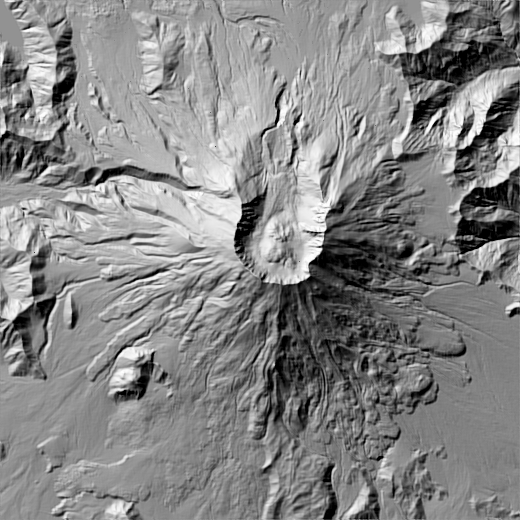

In [3]:
def show(path, width=520):
    png = preview.raster_preview(str(path))
    return Image(data=base64.b64decode(png['png_data_uri'].split(',', 1)[1]), width=width)

show(data / 'hillshade.tif')

## Flow accumulation

`log_transform=True` is how you actually see a drainage network: raw D8 counts
are 1 almost everywhere and enormous in the channels.

In [4]:
acc = whitebox_engine.flow_accumulation(str(dem_path), str(data / 'flowacc.tif'),
                                       log_transform=True)
acc

{'output': 'data\\flowacc.tif',
 'method': 'd8',
 'out_type': 'cells',
 'provenance': 'data\\flowacc.tif.provenance.json',
 'verified': True}

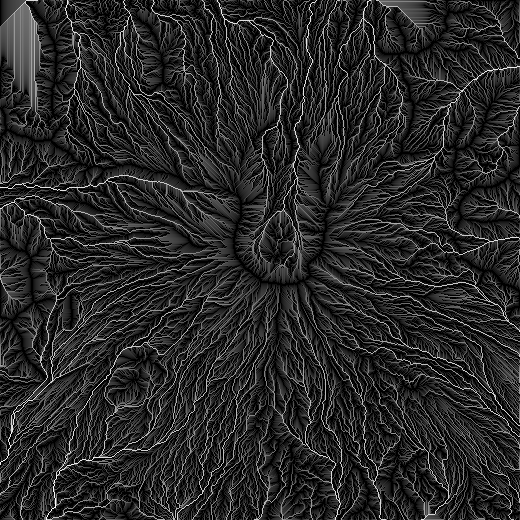

In [5]:
show(data / 'flowacc.tif')

## Watersheds above real outlets

`watershed` takes many pour points at once and numbers the basins 1..N in
feature order. The outlets here are picked from the data rather than by hand:
the border cells where the largest channels leave the grid, kept apart so each
one drains a different flank of the volcano.

In [6]:
import geopandas as gpd
from shapely.geometry import Point

with rasterio.open(data / 'flowacc.tif') as src:
    grid = src.read(1)
    rows, cols = grid.shape
    border = ([(1, c) for c in range(1, cols - 1)]
              + [(rows - 2, c) for c in range(1, cols - 1)]
              + [(r, 1) for r in range(1, rows - 1)]
              + [(r, cols - 2) for r in range(1, rows - 1)])
    border.sort(key=lambda rc: -grid[rc])
    outlets = []
    for rc in border:  # keep them apart so the basins are distinct flanks
        if all(abs(rc[0] - o[0]) + abs(rc[1] - o[1]) > 120 for o in outlets):
            outlets.append(rc)
        if len(outlets) == 6:
            break
    points = [Point(*src.xy(*rc)) for rc in outlets]

gpd.GeoDataFrame({'id': range(1, len(points) + 1)}, geometry=points,
                 crs='EPSG:32610').to_file(data / 'outlets.gpkg')
ws = whitebox_engine.watershed(str(dem_path), str(data / 'outlets.gpkg'),
                               str(data / 'basins.tif'))
ws

{'output': 'data\\basins.tif',
 'n_pour_points': 6,
 'provenance': 'data\\basins.tif.provenance.json',
 'verified': True}

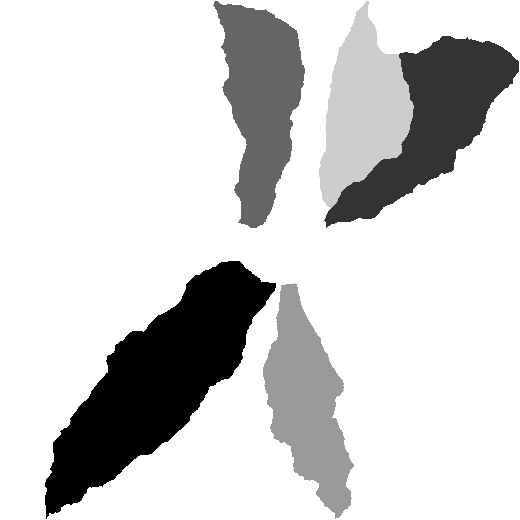

In [7]:
# six catchments, one grey level each; everything draining elsewhere is nodata
show(data / 'basins.tif')

## Zonal statistics on the DEM

exactextract computes statistics with exact fractional pixel coverage — no
all-in/all-out pixel approximation at the zone boundary.

In [8]:
from shapely.geometry import box
from mapsmith.engines import raster

with rasterio.open(dem_path) as dem:
    left, bottom, right, top = dem.bounds
mid = (left + right) / 2

zones = gpd.GeoDataFrame(
    {'side': ['west flank', 'east flank']},
    geometry=[box(left, bottom, mid, top), box(mid, bottom, right, top)],
    crs='EPSG:32610')
zones.to_parquet(data / 'zones.parquet')

raster.zonal_statistics(str(dem_path), str(data / 'zones.parquet'),
                        str(data / 'zone_elevation.parquet'),
                        ['mean', 'min', 'max'])
gpd.read_parquet(data / 'zone_elevation.parquet')[['side', 'mean', 'min', 'max']]

,side,mean,min,max
0,west flank,1232.196376,786,2534
1,east flank,1317.243077,652,2527


## What the manifests say

Every raster above carries its own provenance manifest with the deterministic
checks that were run — including the disclosure that MapSmith rewrote the
input into a layout the engine handles correctly.

In [9]:
from mapsmith.provenance import read_provenance

manifest = read_provenance(str(data / 'hillshade.tif'))
print('operation:', manifest['operation'], '| engine:', manifest['engine'])
print('checks:', [(c['name'], c['passed']) for c in manifest['verification']])
for note in manifest['notes']:
    print('note:', note)

operation: hillshade | engine: {'name': 'whitebox-workflows', 'version': '2.0.6'}
checks: [('crs_present', True), ('crs_matches', True), ('dimensions_match_input', True), ('has_valid_cells', True), ('values_in_expected_range', True)]
note: input GeoTIFF is stored with TIFF predictor 2; the engine was given a copy with identical values and no predictor, because whitebox_workflows 2.x does not undo the TIFF predictor when decompressing (see _needs_plain_copy for the measurements)
